# Jordskjelv

Bruker en fil med over 200 000 jordskjelv fra 1973 og til 2014.

In [2]:
import pandas as pd

data_J = pd.read_csv("NEIC_global_1973-2014.txt", sep='\t', decimal = ',')  # Jordskjelvdata (tab som separator)
data_J.head(10)                                                             # Printer de 10 første radene 

,Year,Month,Day,UT-Time,Latit,Longit,Depth,Magnitude
1,1973,1,1,3.77,-9.21,150.63,41.0,5.3
2,1973,1,1,5.37,-15.01,-173.96,33.0,5.0
3,1973,1,1,9.48,-22.16,-65.79,205.0,4.8
4,1973,1,1,11.71,-35.51,-16.21,33.0,6.0
5,1973,1,2,0.89,-9.85,117.43,66.0,5.5
6,1973,1,2,2.45,1.03,126.21,61.0,5.4
7,1973,1,2,3.06,18.92,-104.13,33.0,4.6
8,1973,1,2,3.79,5.40,-82.54,30.0,5.2
9,1973,1,2,13.86,71.53,-5.75,33.0,4.5
10,1973,1,2,16.42,36.08,71.31,137.0,4.8


In [3]:
print(max(data_J["Latit"])) # y-akse (kommer først)
print(min(data_J["Latit"]))
print(max(data_J["Longit"])) # x-akse (siste)
print(min(data_J["Longit"]))
print(max(data_J["Depth"])) # maks er 700
print(min(data_J["Depth"])) # min er 0 (??)
print(max(data_J["Magnitude"])) # maks er 9.1
print(min(data_J["Magnitude"])) # Min er 4.5

87.22
-84.13
180.0
-180.0
700.0
0.0
9.1
4.5


<BarContainer object of 50 artists>

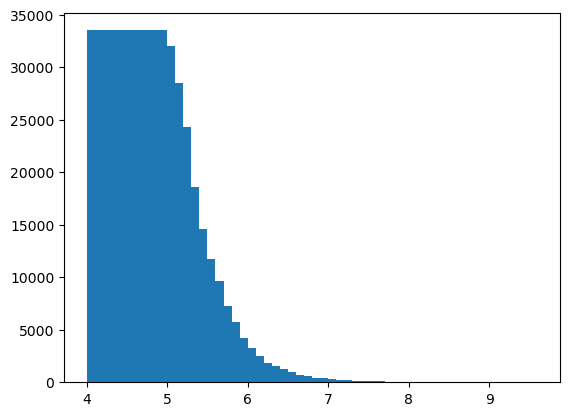

In [3]:
# Plotter antall skjelv av de ulike typene

import numpy as np
import matplotlib.pyplot as plt

values, counts = np.unique((data_J["Magnitude"]).values, return_counts = True)
plt.bar(values, counts, width = 1.0)

<BarContainer object of 7616 artists>

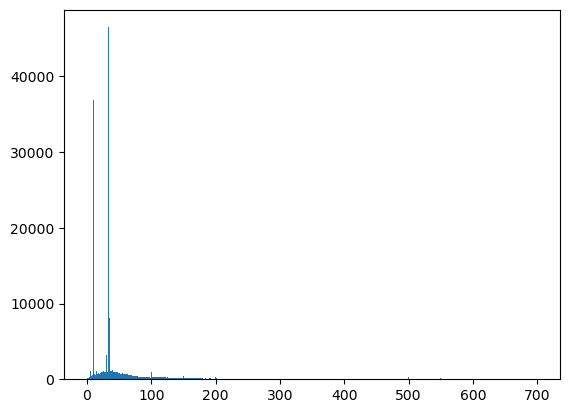

In [3]:
# Plotter antall skjelv ved ulike dybder

values, counts = np.unique((data_J["Depth"]).values, return_counts = True)
plt.bar(values, counts, width = 1.0)

1     -41.0
2     -33.0
3    -205.0
4     -33.0
5     -66.0
6     -61.0
7     -33.0
8     -30.0
9     -33.0
10   -137.0
Name: Depth, dtype: float64


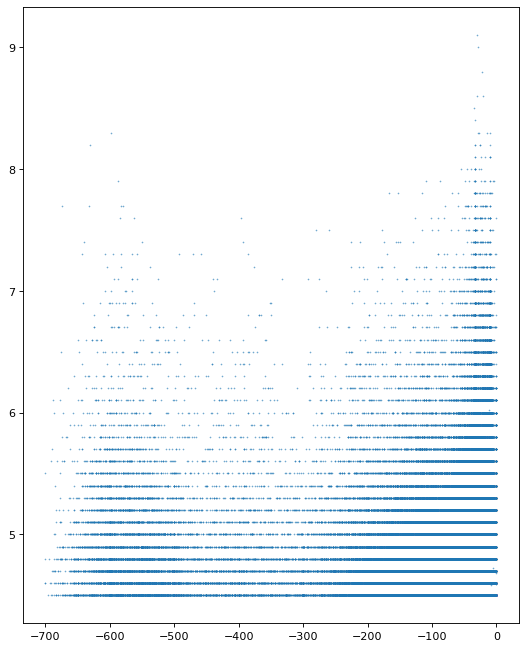

In [5]:
# Plotter dybde mot styrke

dybde = data_J["Depth"]
dybde = dybde*(-1)
styrke = data_J["Magnitude"]
print(dybde[0:10])

plt.figure(figsize=(8, 10), dpi=80)
plt.scatter(dybde, styrke, s = 0.1)

Henter området vi vil plotte jordskjelv over fra https://www.openstreetmap.org/export#map=5/51.500/-0.100

Skriv inn begrensningene for lengde og breddegrad og last ned

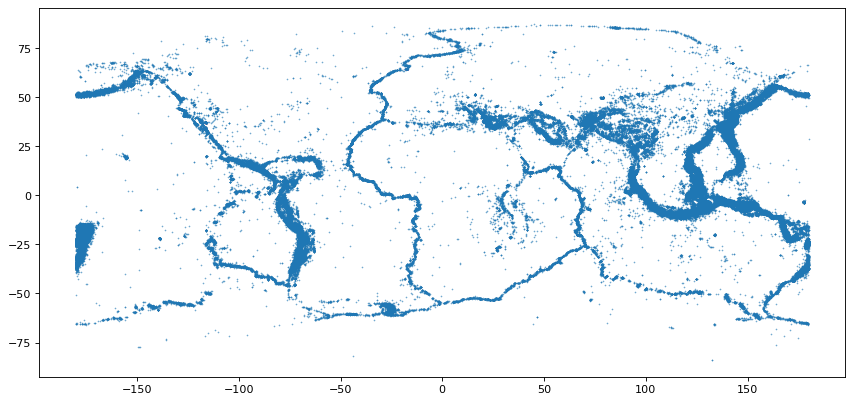

In [4]:
# Plotter posisjon

lengdegrad = data_J["Latit"]
breddegrad = data_J["Longit"]

plt.figure(figsize=(13, 6), dpi=80)
plt.scatter(breddegrad, lengdegrad, s = 0.1)

Text(0, 0.5, 'Lengdegrad')

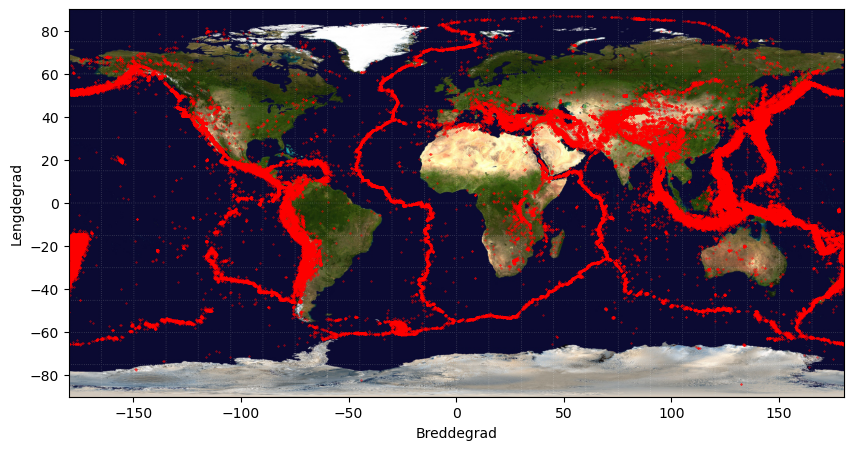

In [5]:
# Plotter posisjon overlagt et kart

import matplotlib.pyplot as plt

img = plt.imread("Equirectangular-projection.jpg")
fig, ax = plt.subplots(figsize=(10, 12), dpi=100)
ax.imshow(img, extent=[-180, 180, -90, 90])

plt.scatter(breddegrad, lengdegrad, s = 0.1, color = 'r')
plt.xlabel('Breddegrad')
plt.ylabel('Lengdegrad')

Kartet er et rektangelkart med ekvidistanse både langs lengde- og breddegradene. Kartet er hentet fra https://simple.wikipedia.org/wiki/Equirectangular_projection

Hva er den laveste styrken du vil plotte?  8


Text(0, 0.5, 'Lengdegrad')

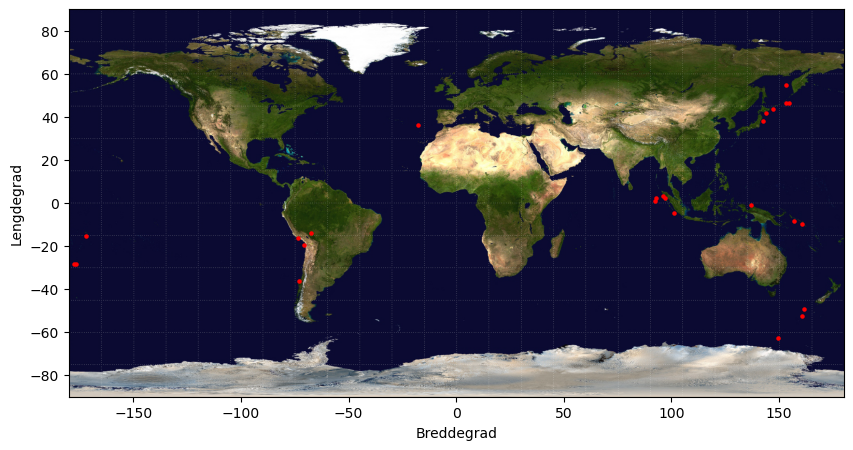

In [6]:
# Plotter alle over en gitt styrke

import matplotlib.pyplot as plt

img = plt.imread("Equirectangular-projection.jpg")
fig, ax = plt.subplots(figsize=(10, 12), dpi=100)
ax.imshow(img, extent=[-180, 180, -90, 90])

styrke = float(input("Hva er den laveste styrken du vil plotte? "))

mag = data_J["Magnitude"]
leng = data_J["Latit"]
bred = data_J["Longit"]

n = len(data_J["Magnitude"])
lg = []
bg = []
for i in range(n):
    if mag[i+1] > styrke:
        lg.append(leng[i+1])
        bg.append(bred[i+1])   

plt.scatter(bg, lg, s = 5, color = 'r')
plt.xlabel('Breddegrad')
plt.ylabel('Lengdegrad')

Hvilket år vil du plotte (1973 - 2014)? 2010


Text(0, 0.5, 'Lengdegrad')

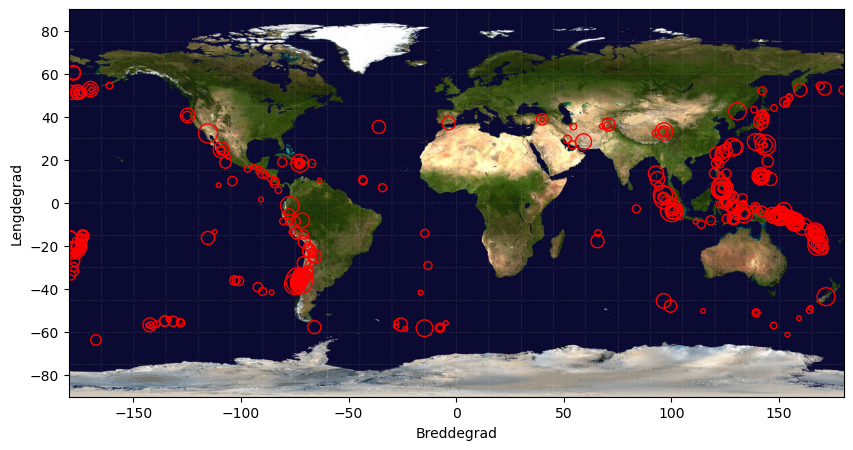

In [6]:
# Plotter styrke som størrlse

import matplotlib.pyplot as plt

img = plt.imread("Equirectangular-projection.jpg")
fig, ax = plt.subplots(figsize=(10, 12), dpi=100)
ax.imshow(img, extent=[-180, 180, -90, 90])

year = float(input("Hvilket år vil du plotte (1973 - 2014)? "))

ar = data_J["Year"]
mag = data_J["Magnitude"]
leng = data_J["Latit"]
bred = data_J["Longit"]

n = len(data_J["Magnitude"])
size = []
lg = []
bg = []

styrke = 5.5

for i in range(n):
    if ar[i+1] == year and mag[i+1] > styrke:
        size.append((mag[i+1]-styrke) * (400/(9.1-styrke))) 
        lg.append(leng[i+1])
        bg.append(bred[i+1])

plt.scatter(bg, lg, s = size, facecolor = 'none', edgecolor = 'r') # Lager sirkler slik at det er letter å skille de ulike styrkene
plt.xlabel('Breddegrad')
plt.ylabel('Lengdegrad')

Hvilket år vil du plotte (1973 - 2014)? 2010


Text(0, 0.5, 'Lengdegrad')

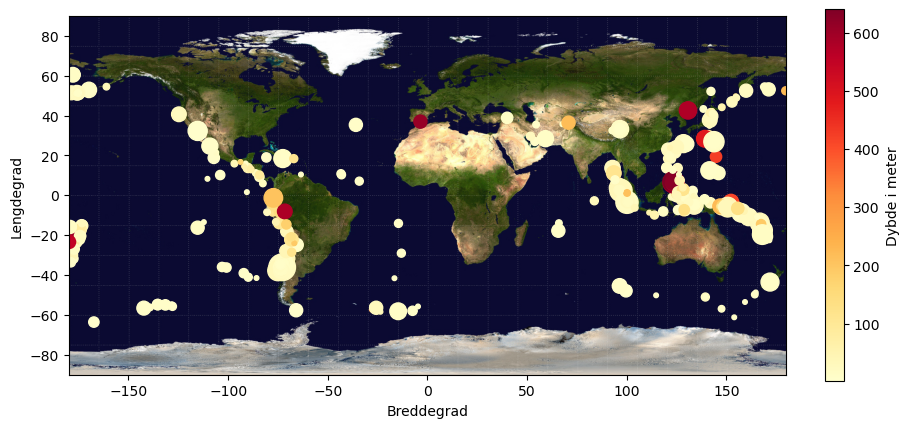

In [9]:
# Plotter styrke som størrlse og dybde med farge

import matplotlib.pyplot as plt

img = plt.imread("Equirectangular-projection.jpg")
fig, ax = plt.subplots(figsize=(10, 12), dpi=100)
ax.imshow(img, extent=[-180, 180, -90, 90])

year = float(input("Hvilket år vil du plotte (1973 - 2014)? "))

ar = data_J["Year"]
mag = data_J["Magnitude"]
leng = data_J["Latit"]
bred = data_J["Longit"]
depth = data_J["Depth"]

n = len(data_J["Magnitude"])
size = []
lg = []
bg = []
dyb = []

styrke = 5.5

for i in range(n):
    if ar[i+1] == year and mag[i+1] > styrke:
        size.append((mag[i+1]-styrke) * (400/(9.1-styrke))) 
        lg.append(leng[i+1])
        bg.append(bred[i+1])
        dyb.append(depth[i+1])

plt.scatter(bg, lg, s = size, c=dyb, cmap = 'YlOrRd') # Lager sirkler slik at det er letter å skille de ulike styrkene
plt.colorbar(label = 'Dybde i meter', fraction = 0.024)
plt.xlabel('Breddegrad')
plt.ylabel('Lengdegrad')

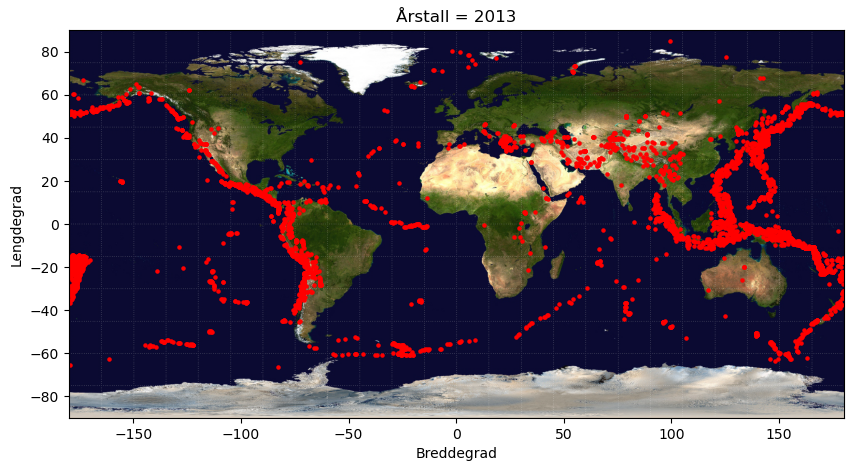

In [7]:
# Plotter animasjon av skjelv per år over gitt styrke

import matplotlib.pyplot as plt
from IPython import display

img = plt.imread("Equirectangular-projection.jpg")
fig, ax = plt.subplots(figsize=(10, 12), dpi=100)
ax.imshow(img, extent=[-180, 180, -90, 90])

styrke = float(input("Hva er den laveste styrken du vil plotte? "))

mag = data_J["Magnitude"]
leng = data_J["Latit"]
bred = data_J["Longit"]
n = len(data_J["Magnitude"])
lg = []
bg = []
startar = data_J["Year"][1]
ar = data_J["Year"][1]

for i in range(n):
    if mag[i+1] > styrke:
        startar = data_J["Year"][i+1]
        lg.append(leng[i+1])
        bg.append(bred[i+1])

    if ar != startar:                              
        #figure(figsize=(10,10))
        display.clear_output(wait=True)             # Her oppdatere vi plottet vårt
        img = plt.imread("Equirectangular-projection.jpg")
        fig, ax = plt.subplots(figsize=(10, 12), dpi=100)
        ax.imshow(img, extent=[-180, 180, -90, 90])
        plt.scatter(bg, lg, s = 5, color = 'r')
        plt.xlabel('Breddegrad')
        plt.ylabel('Lengdegrad')
        tid = "Årstall = " + str(ar)
        plt.title(tid)
        plt.pause(0.3)                                  # Pause mellom hver gang den oppdaterer plottet i sekunder
        ar = startar
        